Objective:

Leverage ARIMA and Exponential Smoothing techniques to forecast future exchange rates based on historical data provided in the exchange_rate.csv dataset.

Dataset:

The dataset contains historical exchange rate with each column representing a different currency rate over time. The first column indicates the date, and second column represent exchange rates USD to Australian Dollar.



Part 1: Data Preparation and Exploration
1.	Data Loading: Load the exchange_rate.csv dataset and parse the date column appropriately.
2.	Initial Exploration: Plot the time series for currency to understand their trends, seasonality, and any anomalies.
3.	Data Preprocessing: Handle any missing values or anomalies identified during the exploration phase.


In [146]:
#load the dataset
import pandas as pd
df=pd.read_csv('/content/exchange_rate.csv',index_col=['date'],parse_dates=True)
df.head()

,Ex_rate
date,
01-01-1990 00:00,0.7855
02-01-1990 00:00,0.7818
03-01-1990 00:00,0.7867
04-01-1990 00:00,0.7860
05-01-1990 00:00,0.7849


In [148]:
df.index.dtype

dtype('O')

In [149]:
df.index=pd.to_datetime(df.index,format="%d-%m-%Y %H:%M")

In [150]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7588 entries, 1990-01-01 to 2010-10-10
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ex_rate  7588 non-null   float64
dtypes: float64(1)
memory usage: 118.6 KB


In [151]:
# initial exploration
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

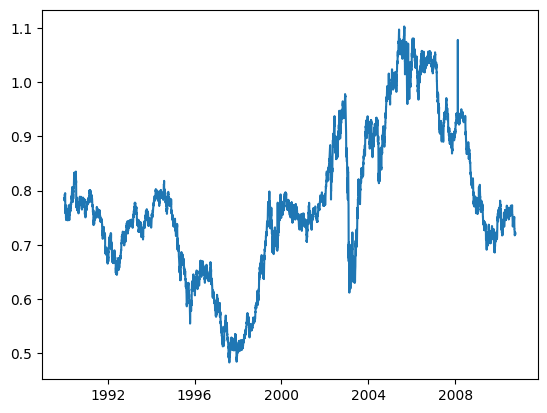

In [152]:
plt.plot(df)

In [153]:
model=seasonal_decompose(df['Ex_rate'],model='multiplicative',period=365)

<Axes: xlabel='date'>

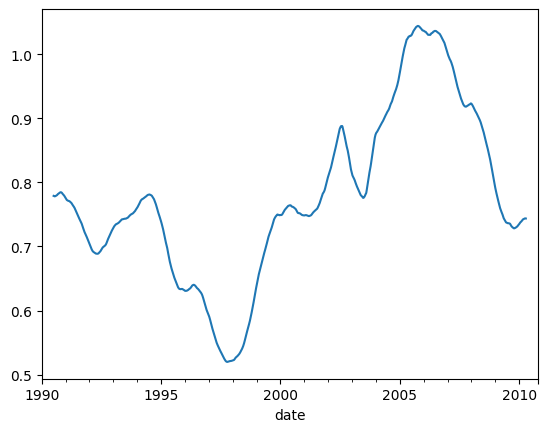

In [154]:
model.trend.plot()

<Axes: xlabel='date'>

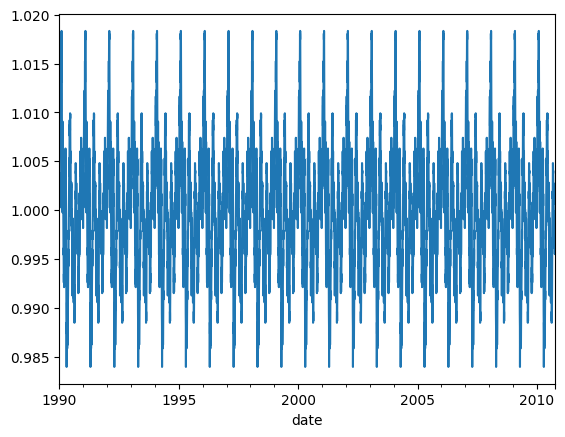

In [155]:
model.seasonal.plot()

<Axes: xlabel='date'>

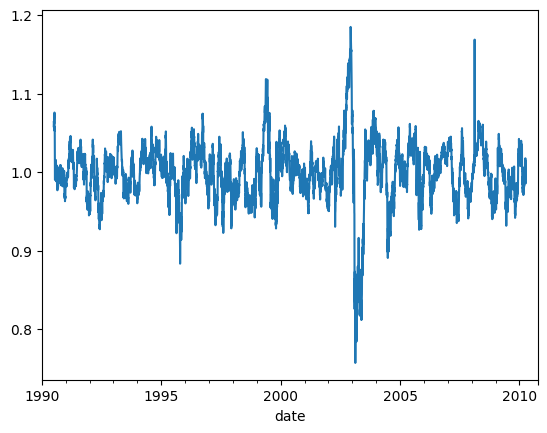

In [156]:
model.resid.plot()

In [157]:
#checking for missing values
df.isnull().sum()

,0
Ex_rate,0


Part 2: Model Building - ARIMA
1.	Parameter Selection for ARIMA: Utilize ACF and PACF plots to estimate initial parameters (p, d, q) for the ARIMA model for one or more currency time series.
2.	Model Fitting: Fit the ARIMA model with the selected parameters to the preprocessed time series.
3.	Diagnostics: Analyze the residuals to ensure there are no patterns that might indicate model inadequacies.
4.	Forecasting: Perform out-of-sample forecasting and visualize the predicted values against the actual values.


In [158]:
from statsmodels.tsa.stattools import adfuller,pacf,acf

In [159]:
# check for stationarity
def test_stationarity(timeseries):
  rollmean=timeseries.rolling(window=12).mean()
  rollstd=timeseries.rolling(window=12).std()

  print('Results of Dickey Fuller Test:\n')
  df_test=adfuller(timeseries)
  my_output=pd.Series(df_test[0:4],index=['Stats value','pvalue','lags','observations'])
  for i,j in df_test[4].items():
    my_output['Critical Value(%s)' %i]=j
  print(my_output)

In [160]:
test_stationarity(df['Ex_rate'])

Results of Dickey Fuller Test:

Stats value              -1.664994
pvalue                    0.449233
lags                      1.000000
observations           7586.000000
Critical Value(1%)       -3.431212
Critical Value(5%)       -2.861921
Critical Value(10%)      -2.566973
dtype: float64


In [161]:
#differencing
df['ex_rate_Diff']=df['Ex_rate']-df['Ex_rate'].shift(365)
df.dropna(inplace=True)
test_stationarity(df['ex_rate_Diff'])

Results of Dickey Fuller Test:

Stats value              -3.501093
pvalue                    0.007959
lags                     29.000000
observations           7193.000000
Critical Value(1%)       -3.431259
Critical Value(5%)       -2.861942
Critical Value(10%)      -2.566984
dtype: float64


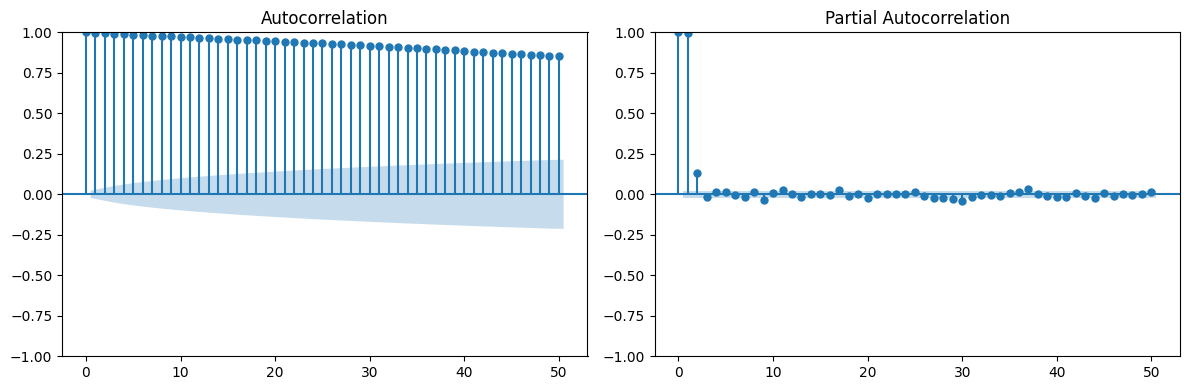

In [162]:
# acf and pacf
import statsmodels.tsa.api as smt
fig,axes=plt.subplots(1,2)
fig.set_figwidth(12)
fig.set_figheight(4)
smt.graphics.plot_acf(df['ex_rate_Diff'],lags=50,ax=axes[0])
smt.graphics.plot_pacf(df['ex_rate_Diff'],lags=50,ax=axes[1])
plt.tight_layout()

In [163]:
# ARIMA
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

In [164]:
model=ARIMA(df['Ex_rate'],order=(1,1,1))

In [165]:
result=model.fit()

In [166]:
df['predicted']=result.predict()

In [167]:
forecast=result.forecast(20)

In [168]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(df['Ex_rate'],df['predicted'])

0.0038259841795961116

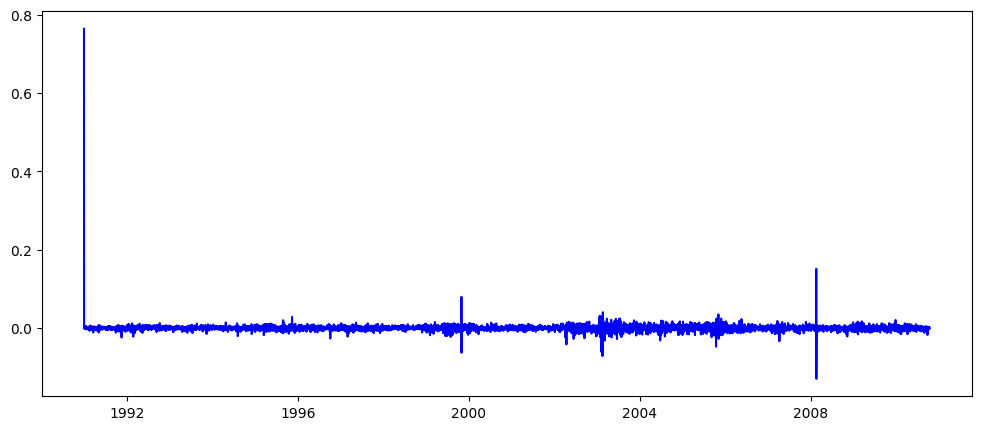

In [171]:
#diagnostics of residuals
residuals=result.resid
plt.figure(figsize=(12, 5))
plt.plot(residuals, label="Residuals", color="blue")
plt.show()

In [169]:
from pandas.tseries.offsets import DateOffset

<Axes: >

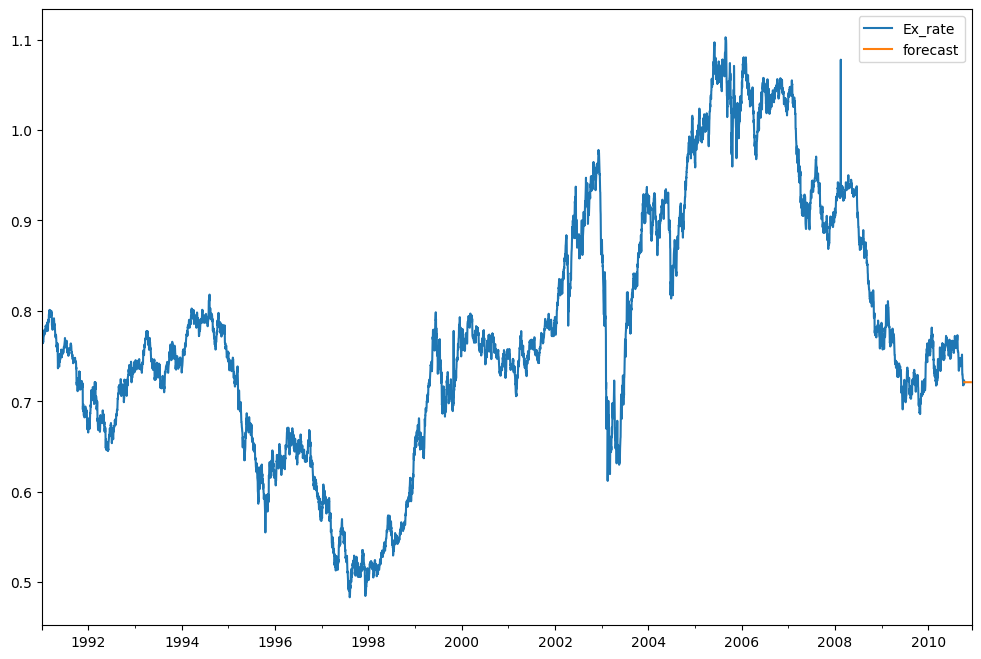

In [170]:
pred_date=[df.index[-1]+ DateOffset(days=x) for x in range(0,60)]
pred_date_df=pd.DataFrame(index=pred_date[1:])

data=pd.concat([df,pred_date_df])
data['forecast']=result.predict(start="2010-10-10",end="2010-11-30",dynamic=True)
data[['Ex_rate','forecast']].plot(figsize=(12,8))

Part 3: Model Building - Exponential Smoothing
1.	Model Selection: Depending on the time series characteristics, choose an appropriate Exponential Smoothing model (Simple, Holt’s Linear, or Holt-Winters).
2.	Parameter Optimization: Use techniques such as grid search or AIC to find the optimal parameters for the smoothing levels and components.
3.	Model Fitting and Forecasting: Fit the chosen Exponential Smoothing model and forecast future values. Compare these forecasts visually with the actual data.


In [173]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing,ExponentialSmoothing

In [174]:
# simple Exp Smoothing
simple=SimpleExpSmoothing(df['Ex_rate']).fit(smoothing_level=0.5)

In [175]:
simple.fittedvalues

,0
date,
1991-01-01,0.764500
1991-01-02,0.764500
1991-01-03,0.764750
1991-01-04,0.765875
1991-01-05,0.766687
...,...
2010-10-06,0.719158
2010-10-07,0.718826
2010-10-08,0.720332


In [184]:
forecast_simple=simple.forecast(500)
print(type(forecast_simple))

<class 'pandas.core.series.Series'>


In [185]:
df['SES']=SimpleExpSmoothing(df['Ex_rate']).fit(smoothing_level=0.5).fittedvalues

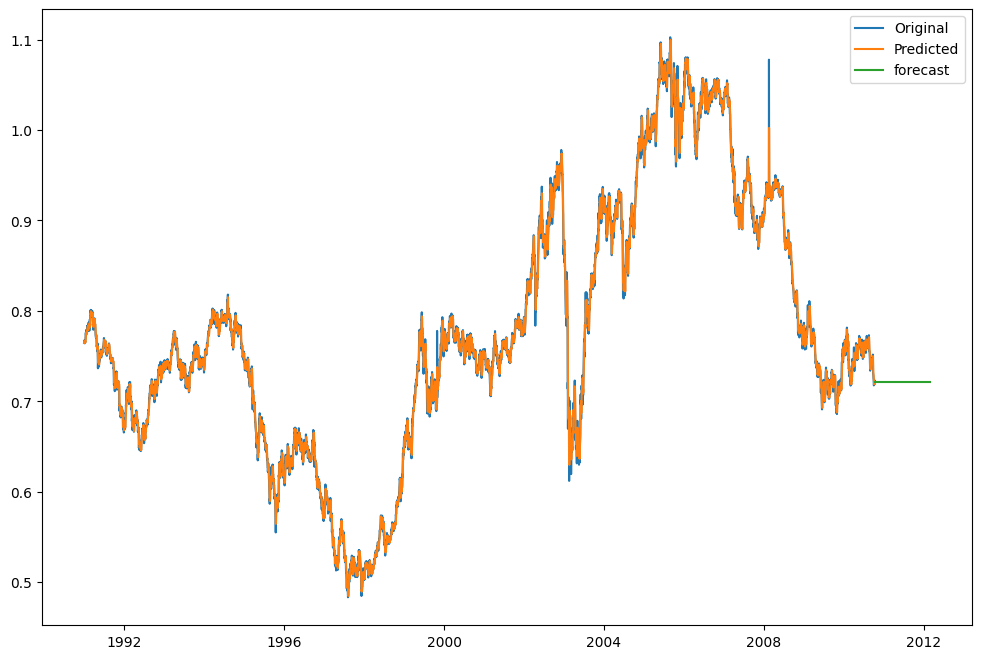

In [186]:
plt.figure(figsize=(12,8))
plt.plot(df['Ex_rate'],label='Original')
plt.plot(df['SES'],label='Predicted')
plt.plot(forecast_simple,label='forecast')
plt.legend()

In [187]:
# Double Exp Smoothing
double=ExponentialSmoothing(df['Ex_rate'],trend='multiplicative').fit(smoothing_level=0.5,smoothing_trend=0.5)

In [188]:
double.fittedvalues

,0
date,
1991-01-01,0.765539
1991-01-02,0.765335
1991-01-03,0.765399
1991-01-04,0.766832
1991-01-05,0.767967
...,...
2010-10-06,0.718488
2010-10-07,0.718487
2010-10-08,0.720999


In [189]:
forecast_double=double.forecast(500)

In [190]:
df['DES']=double.fittedvalues

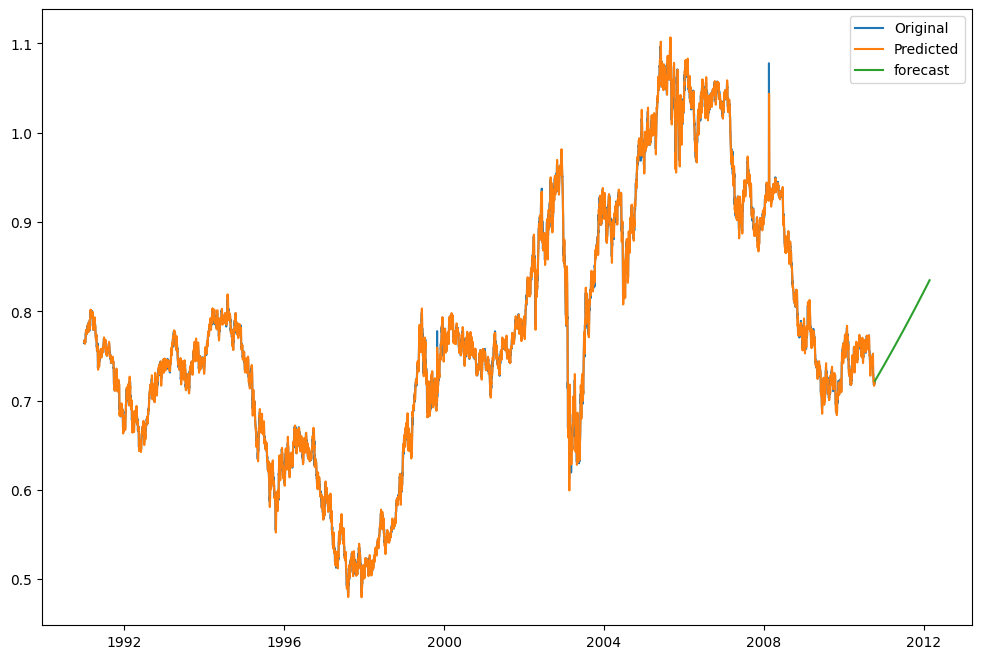

In [192]:
plt.figure(figsize=(12,8))
plt.plot(df['Ex_rate'],label='Original')
plt.plot(df['DES'],label='Predicted')
plt.plot(forecast_double,label='forecast')
plt.legend()

In [193]:
# triple Exp Smoothing
triple=ExponentialSmoothing(df['Ex_rate'],trend='multiplicative',seasonal='multiplicative').fit(smoothing_level=0.5,smoothing_trend=0.5,smoothing_seasonal=0.5)

In [194]:
triple.fittedvalues

,0
date,
1991-01-01,0.764529
1991-01-02,0.763953
1991-01-03,0.766699
1991-01-04,0.768928
1991-01-05,0.770186
...,...
2010-10-06,0.713800
2010-10-07,0.709076
2010-10-08,0.716370


In [196]:
forecast_triple=triple.forecast(500)

In [197]:
df['TES']=triple.fittedvalues

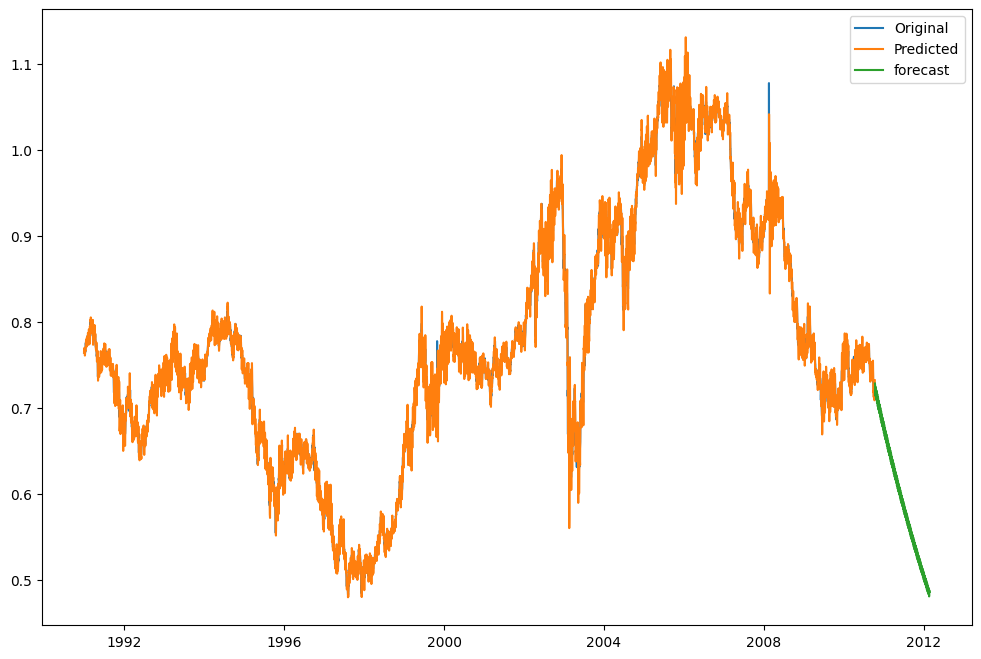

In [199]:
plt.figure(figsize=(12,8))
plt.plot(df['Ex_rate'],label='Original')
plt.plot(df['TES'],label='Predicted')
plt.plot(forecast_triple,label='forecast')
plt.legend()

Part 4: Evaluation and Comparison
1.	Compute Error Metrics: Use metrics such as MAE, RMSE, and MAPE to evaluate the forecasts from both models.
2.	Model Comparison: Discuss the performance, advantages, and limitations of each model based on the observed results and error metrics.
3.	Conclusion: Summarize the findings and provide insights on which model(s) yielded the best performance for forecasting exchange rates in this dataset.


In [200]:
from sklearn.metrics import mean_absolute_error,mean_absolute_percentage_error,mean_squared_error

In [207]:
#mean_squared_error
mse_SES=mean_squared_error(df['Ex_rate'],df['SES'])
mse_DES=mean_squared_error(df['Ex_rate'],df['DES'])
mse_TES=mean_squared_error(df['Ex_rate'],df['TES'])
print(mse_SES,mse_DES,mse_TES)

4.333186135574087e-05 4.901466683984134e-05 0.0001465404192861375


In [209]:
#mean_absolute_error
mae_SES=mean_absolute_error(df['Ex_rate'],df['SES'])
mae_DES=mean_absolute_error(df['Ex_rate'],df['DES'])
mae_TES=mean_absolute_error(df['Ex_rate'],df['TES'])
print(mae_SES,mae_DES,mae_TES)

0.004354626432480704 0.004660507209895069 0.008669801917970963


In [210]:
#mean_absolute_percentage_error
mape_SES=mean_absolute_percentage_error(df['Ex_rate'],df['SES'])
mape_DES=mean_absolute_percentage_error(df['Ex_rate'],df['DES'])
mape_TES=mean_absolute_percentage_error(df['Ex_rate'],df['TES'])
print(mape_SES,mape_DES,mape_TES)

0.005681214967112686 0.006083424545503183 0.011201051018216326


In [211]:
#root_mean_squared_error
import numpy as np
rmse_SES=np.sqrt(mean_squared_error(df['Ex_rate'],df['SES']))
rmse_DES=np.sqrt(mean_squared_error(df['Ex_rate'],df['DES']))
rmse_TES=np.sqrt(mean_squared_error(df['Ex_rate'],df['TES']))
print(rmse_SES,rmse_DES,rmse_TES)

0.0065826940803702 0.007001047553033856 0.012105388027078582


In [212]:
# ARIMA model
mse_ARIMA=mean_squared_error(df['Ex_rate'],df['predicted'])
mae_ARIMA=mean_absolute_error(df['Ex_rate'],df['predicted'])
mape_ARIMA=mean_absolute_percentage_error(df['Ex_rate'],df['predicted'])
rmse_ARIMA=np.sqrt(mse_ARIMA)

In [213]:
print(mse_ARIMA,mae_ARIMA,mape_ARIMA,rmse_ARIMA)

0.00011764660534328008 0.0038259841795961116 0.00499804351920643 0.010846501986506068


In [214]:
'''
arima:
-- It is applicable if the bussiness has trend and not for seasonal

Simple Exp. Smoothing:
-- It is applicale if the bussiness has level .

Double Exp. Smoothing:
-- It is applicale if the bussiness has level and trend .

Triple Exp. Smoothing:
-- It is applicale if the bussiness has level,trend and seasonal .

'''


'\narima:\n-- It is applicable if the bussiness has trend and not for seasonal\n\nSimple Exp. Smoothing:\n-- It is applicale if the bussiness has level .\n\nDouble Exp. Smoothing:\n-- It is applicale if the bussiness has level and trend .\n\nTriple Exp. Smoothing:\n-- It is applicale if the bussiness has level,trend and seasonal .\n\n'

In [215]:
'''
Conclusion:
 --- Since  ARIMA model has the lowest error compared to exponential smoothing techniques.
 --- it is cleared that the business has only trend.
 --- the bussiness has no seasonal.
 '''

'\nConclusion:\n --- Since  ARIMA model has the lowest error compared to exponential smoothing techniques.\n --- it is cleared that the business has only trend.\n --- the bussiness has no seasonal.\n '